In [1]:
import duckdb

In [2]:
con = duckdb.connect()

con.execute("PRAGMA enable_progress_bar")

In [4]:
schema = con.execute("""

    DESCRIBE

    SELECT * FROM read_parquet('/Volumes/travelpassport/tables/dvt_less_than_5.parquet')

""").fetchdf()

print(schema)

    column_name column_type null   key default extra
0     source_id      BIGINT  YES  None    None  None
1            ra      DOUBLE  YES  None    None  None
2      ra_error       FLOAT  YES  None    None  None
3           dec      DOUBLE  YES  None    None  None
4     dec_error       FLOAT  YES  None    None  None
..          ...         ...  ...   ...     ...   ...
62    proj_vdec      DOUBLE  YES  None    None  None
63    delta_vra      DOUBLE  YES  None    None  None
64   delta_vdec      DOUBLE  YES  None    None  None
65     delta_vT      DOUBLE  YES  None    None  None
66  sphere_name     VARCHAR  YES  None    None  None

[67 rows x 6 columns]


In [6]:
schema.column_name.values

<StringArray>
[               'source_id',                       'ra',
                 'ra_error',                      'dec',
                'dec_error',                 'parallax',
           'parallax_error',      'parallax_over_error',
                       'pm',                     'pmra',
               'pmra_error',                    'pmdec',
              'pmdec_error',                     'ruwe',
         'phot_g_mean_flux',   'phot_g_mean_flux_error',
          'phot_g_mean_mag',        'phot_bp_mean_flux',
  'phot_bp_mean_flux_error',         'phot_bp_mean_mag',
        'phot_rp_mean_flux',  'phot_rp_mean_flux_error',
         'phot_rp_mean_mag', 'phot_bp_rp_excess_factor',
                    'bp_rp',                     'bp_g',
                     'g_rp',          'radial_velocity',
    'radial_velocity_error',                        'l',
                        'b',        'has_xp_continuous',
                  'has_rvs',                        'X',
                 

```SQL

SELECT ra, dec, parallax, parallax_error, pmra, pmra_error, pmdec, 
       pmdec_error, ruwe, phot_g_mean_mag, phot_bp_mean_mag, 
       phot_rp_mean_mag, radial_velocity, radial_velocity_error,
       l, b, X, Y, Z, U, V, W, ocmg_name_1_HR24, mem_prob_1_HR24,
       vra, vdec, proj_vra, proj_vdec, delta_vT, sphere_name
FROM read_parquet('/Volumes/travelpassport/tables/dvt_less_than_5.parquet')
WHERE delta_vT < 3
       
```

In [3]:
con.execute("""


    SELECT COUNT(*)
    
    FROM read_parquet('/Volumes/travelpassport/tables/dvt_less_than_5.parquet')
                                 
""").fetchdf()

,count_star()
0,64819864


In [7]:
df = con.execute("""


    SELECT delta_vT
    
    FROM read_parquet('/Volumes/travelpassport/tables/dvt_less_than_5.parquet')
                 
    USING SAMPLE 648198 ROWS
                 
""").fetchdf()

100% ▕██████████████████████████████████████▏ (00:00:19.99 elapsed)     


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

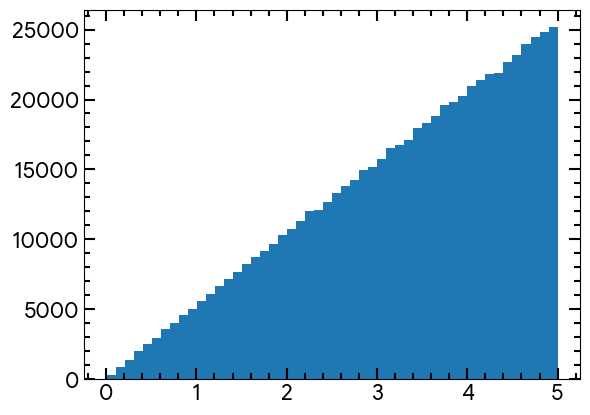

In [8]:
plt.hist(df.delta_vT, bins=50)
plt.show()

In [17]:
df.ocmg_name_1_HR24.isna().sum()

np.int64(99925)

In [18]:
df.ocmg_name_1_HR24.value_counts()

ocmg_name_1_HR24
Theia 242    60
Theia 817    12
HSC 384       2
ASCC 104      1
Name: count, dtype: int64

In [13]:
query = """

SELECT source_id, ra, dec, parallax, parallax_error, pmra, pmra_error, pmdec, 
       pmdec_error, ruwe, phot_g_mean_mag, phot_bp_mean_mag, 
       phot_rp_mean_mag, radial_velocity, radial_velocity_error,
       l, b, X, Y, Z, U, V, W, ocmg_name_1_HR24, mem_prob_1_HR24,
       vra, vdec, proj_vra, proj_vdec, delta_vT, sphere_name
FROM read_parquet('/Volumes/travelpassport/tables/dvt_less_than_5.parquet')
WHERE delta_vT < 3

"""

df = con.execute(query).fetchdf()

100% ▕██████████████████████████████████████▏ (00:00:03.45 elapsed)     
 99% ▕█████████████████████████████████████▌▏ (<1 second remaining)     

In [14]:
df

,source_id,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,ruwe,...,V,W,ocmg_name_1_HR24,mem_prob_1_HR24,vra,vdec,proj_vra,proj_vdec,delta_vT,sphere_name
0,4483966133571363328,277.328546,11.665881,2.992912,1.739107,0.081223,1.420522,-2.166591,1.498762,1.134894,...,NaN,NaN,NaN,NaN,0.128649,-3.431661,-1.407896,-5.740750,2.773601,ASCC_101
1,4485053172609012352,275.539419,12.437468,2.880812,0.831941,-0.145083,0.891916,-3.101577,0.876663,1.049128,...,NaN,NaN,NaN,NaN,-0.238739,-5.103746,-1.931641,-5.504529,1.739697,ASCC_101
2,4484037842338615296,277.805685,11.489534,2.975091,1.297854,0.447619,1.515172,-4.613999,1.563106,0.975867,...,NaN,NaN,NaN,NaN,0.713230,-7.351883,-1.267967,-5.794942,2.519763,ASCC_101
3,4484302000012956928,276.206357,12.265546,2.832917,0.953880,-0.466070,1.234109,-2.376125,0.843249,1.036717,...,NaN,NaN,NaN,NaN,-0.779899,-3.976095,-1.736596,-5.555065,1.846190,ASCC_101
4,4484034097135808128,276.878507,11.867748,2.788338,1.118290,0.696202,1.229675,-2.869004,1.146930,1.098739,...,NaN,NaN,NaN,NaN,1.183616,-4.877611,-1.539789,-5.678490,2.838722,ASCC_101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23618959,6733520847608330368,279.415304,-36.583238,5.438820,0.581512,2.378331,0.617225,-17.823599,0.510837,3.378523,...,NaN,NaN,NaN,NaN,2.072950,-15.535031,0.935623,-16.973663,1.833897,beta_Tuc_Group
23618960,1445761931151292416,199.691169,22.752136,9.098638,0.059587,-26.277775,0.065545,-20.358094,0.039926,1.098174,...,NaN,NaN,NaN,NaN,-13.690951,-10.606746,-11.945755,-9.862128,1.897410,beta_Tuc_Group
23618961,4043991711000658432,269.528645,-31.587813,5.753779,1.775689,0.513498,1.896458,-17.582954,1.271294,2.164899,...,NaN,NaN,NaN,NaN,0.423065,-14.486385,-1.191914,-16.659666,2.707638,beta_Tuc_Group
23618962,4056147804317068416,268.009372,-30.662736,5.745957,1.309470,1.730130,1.237319,-19.966530,1.001124,1.546027,...,NaN,NaN,NaN,NaN,1.427374,-16.472581,-1.517288,-16.571673,2.946329,beta_Tuc_Group


In [15]:
df.source_id.nunique()

13749901

<Axes: >

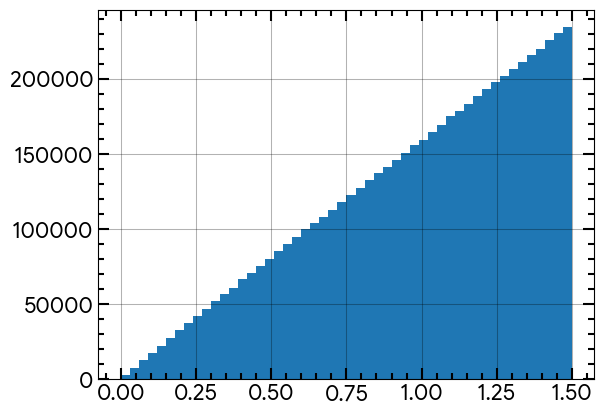

In [11]:
df.loc[df.delta_vT < 1.5, "delta_vT"].hist(bins=50)